# 033 动量学习率与调度

## 目标
把同一组两样本的两次完整反向接到动量更新，再核对学习率时钟和恢复。固定CPU合成实验，不作泛化、GPU性能或大规模模型结论。关键结果：手算loss约0.0221→0.00849256→0.00270862；72更新的小网络中固定动量终点最低；完整恢复逐状态相同。详见lecture.pdf和lab.pdf。

## 设置
先在本讲目录打开Notebook，重启内核，再运行全部。第一格只读文件并检查摘要；未通过时不能继续用旧图解释新数据。

In [1]:
from pathlib import Path
import hashlib, json
HERE = Path.cwd()
expected = json.loads((HERE/'data/figure-input-sha256.json').read_text())
expected.update({'figures/05_quadratic_valley.png': 'c457a9cae3d251eb1fb3182a20fea1cd0591b42eb9a1c5848ad1fed7179775bd', 'figures/06_learning_rate_schedules.png': 'fb9d812546a5a8dd2f9d014da0ac13c39a0e3cef9f6556d1b9350435c12b2936', 'figures/08_network_comparison.png': '12b544f683c57296ade0775709bd1e3d3fb2679db3237ca6bf1d6e1d905b4df1', 'figures/09_resume_state.png': 'a4e60f8e4bab50eeb8e331865118b4bf82649c100e5e274398a9083b18615b06'})
for name, digest in expected.items():
    if hashlib.sha256((HERE/name).read_bytes()).hexdigest() != digest:
        raise ValueError('fixed notebook input changed: '+name)
print('固定输入、8结果和4展示图摘要通过；尚未训练或写输出。')

固定输入、8结果和4展示图摘要通过；尚未训练或写输出。


In [2]:
import sys, numpy as np, torch
import experiment as e
from IPython.display import display, Image
e.configure_cpu()
cfg, hand, X, y = e.read_inputs()
print({'python':sys.version.split()[0], 'numpy':np.__version__, 'torch':torch.__version__, 'device':'cpu', 'dtype':'float64', 'threads':torch.get_num_threads()})
print('网格数据形状', X.shape, y.shape)
print('前3行', np.column_stack([X,y])[:3])

{'python': '3.12.14', 'numpy': '2.3.5', 'torch': '2.7.1+cpu', 'device': 'cpu', 'dtype': 'float64', 'threads': 1}
网格数据形状 (48, 2) (48, 1)
前3行 [[-1.4   -1.     0.1  ]
 [-1.4   -0.6    0.1  ]
 [-1.4   -0.2    0.034]]


## 两次完整手算链
网络权重按输入行、隐藏单元列存储。参数顺序W11,W12,W21,W22,b1,b2,v1,v2,c。两次使用同一X和y；每一步所有坐标都显示，不用省略号。

In [3]:
trace = e.trace_steps(hand)
print(json.dumps({'parameter_order':trace['parameter_order'], 'hand_inputs':hand, 'relu_zero_derivative_convention':trace['relu_zero_derivative_convention']}, ensure_ascii=False, indent=2))

{
  "parameter_order": [
    "W11",
    "W12",
    "W21",
    "W22",
    "b1",
    "b2",
    "v1",
    "v2",
    "c"
  ],
  "hand_inputs": {
    "X": [
      [
        1,
        2
      ],
      [
        -1,
        1
      ]
    ],
    "y": [
      [
        0.7
      ],
      [
        -0.2
      ]
    ],
    "theta": [
      0.5,
      -0.2,
      0.3,
      0.4,
      0.1,
      0.2,
      0.6,
      -0.5,
      0.1
    ],
    "learning_rates": [
      0.1,
      0.05
    ],
    "momentum": 0.8
  },
  "relu_zero_derivative_convention": 0
}


### 第1次前向
先观察全部shape、预激活、ReLU输出、预测、残差、逐样本损失和均值。

In [4]:
s = trace['steps'][0]
forward_keys = ['update_index','shapes','theta','X','y','Z','H','P','residual','per_sample_half_squared_error','loss']
print(json.dumps({k:s[k] for k in forward_keys}, ensure_ascii=False, indent=2))

{
  "update_index": 0,
  "shapes": {
    "X": [
      2,
      2
    ],
    "W": [
      2,
      2
    ],
    "b": [
      2
    ],
    "Z": [
      2,
      2
    ],
    "H": [
      2,
      2
    ],
    "v": [
      2
    ],
    "c": [],
    "P": [
      2,
      1
    ],
    "y": [
      2,
      1
    ],
    "per_sample_parameter_contribution": [
      2,
      9
    ]
  },
  "theta": [
    0.5,
    -0.2,
    0.3,
    0.4,
    0.1,
    0.2,
    0.6,
    -0.5,
    0.1
  ],
  "X": [
    [
      1.0,
      2.0
    ],
    [
      -1.0,
      1.0
    ]
  ],
  "y": [
    [
      0.7
    ],
    [
      -0.2
    ]
  ],
  "Z": [
    [
      1.2000000000000002,
      0.8
    ],
    [
      -0.1,
      0.8
    ]
  ],
  "H": [
    [
      1.2000000000000002,
      0.8
    ],
    [
      0.0,
      0.8
    ]
  ],
  "P": [
    [
      0.42000000000000004
    ],
    [
      -0.30000000000000004
    ]
  ],
  "residual": [
    [
      -0.2799999999999999
    ],
    [
      -0.10000000000000003
  

### 第1次局部导数与路径相加
local_derivatives保存相邻节点的导数。chain按同一图逐层相乘。每样本参数贡献的每一列相加得到完整梯度，均值因子已经包含在预测梯度中。

In [5]:
backward_keys = ['local_derivatives','chain','per_sample_parameter_contribution','gradient','autograd_gradient']
print(json.dumps({k:s[k] for k in backward_keys}, ensure_ascii=False, indent=2))
np.testing.assert_allclose(np.array(s['per_sample_parameter_contribution']).sum(axis=0),s['gradient'],rtol=0,atol=1e-15)

{
  "local_derivatives": {
    "dL_dsample_loss": [
      0.5,
      0.5
    ],
    "dsample_loss_dP": [
      [
        -0.2799999999999999
      ],
      [
        -0.10000000000000003
      ]
    ],
    "dP_dH": [
      [
        0.6,
        -0.5
      ],
      [
        0.6,
        -0.5
      ]
    ],
    "dP_dv": [
      [
        1.2000000000000002,
        0.8
      ],
      [
        0.0,
        0.8
      ]
    ],
    "dP_dc": [
      1.0,
      1.0
    ],
    "dH_dZ": [
      [
        1.0,
        1.0
      ],
      [
        0.0,
        1.0
      ]
    ],
    "dZ_dW_input": [
      [
        1.0,
        2.0
      ],
      [
        -1.0,
        1.0
      ]
    ],
    "dZ_db": [
      [
        1.0,
        1.0
      ],
      [
        1.0,
        1.0
      ]
    ]
  },
  "chain": {
    "dL_dP": [
      [
        -0.13999999999999996
      ],
      [
        -0.05000000000000002
      ]
    ],
    "dL_dH": [
      [
        -0.08399999999999998,
        0.0699999999999

### 第1次动量更新与新的前向
先更新缓冲，再用本次LR乘整个缓冲。全部参数同一步更新完成后才进行新的前向。

In [6]:
update_keys = ['learning_rate','momentum','buffer_before','buffer_after','delta_theta','theta_after','next_forward']
print(json.dumps({k:s[k] for k in update_keys}, ensure_ascii=False, indent=2))

{
  "learning_rate": 0.1,
  "momentum": 0.8,
  "buffer_before": [
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0
  ],
  "buffer_after": [
    -0.08399999999999998,
    0.04499999999999997,
    -0.16799999999999995,
    0.16499999999999998,
    -0.08399999999999998,
    0.09499999999999999,
    -0.16799999999999998,
    -0.152,
    -0.18999999999999997
  ],
  "delta_theta": [
    0.008399999999999998,
    -0.004499999999999997,
    0.016799999999999995,
    -0.016499999999999997,
    0.008399999999999998,
    -0.0095,
    0.0168,
    0.0152,
    0.019
  ],
  "theta_after": [
    0.5084,
    -0.20450000000000002,
    0.31679999999999997,
    0.3835,
    0.10840000000000001,
    0.1905,
    0.6168,
    -0.4848,
    0.11900000000000001
  ],
  "next_forward": {
    "Z": [
      [
        1.2504,
        0.753
      ],
      [
        -0.08319999999999998,
        0.7785000000000001
      ]
    ],
    "H": [
      [
        1.2504,
        0.753
      ],
    

### 第2次前向
先观察全部shape、预激活、ReLU输出、预测、残差、逐样本损失和均值。

In [7]:
s = trace['steps'][1]
forward_keys = ['update_index','shapes','theta','X','y','Z','H','P','residual','per_sample_half_squared_error','loss']
print(json.dumps({k:s[k] for k in forward_keys}, ensure_ascii=False, indent=2))

{
  "update_index": 1,
  "shapes": {
    "X": [
      2,
      2
    ],
    "W": [
      2,
      2
    ],
    "b": [
      2
    ],
    "Z": [
      2,
      2
    ],
    "H": [
      2,
      2
    ],
    "v": [
      2
    ],
    "c": [],
    "P": [
      2,
      1
    ],
    "y": [
      2,
      1
    ],
    "per_sample_parameter_contribution": [
      2,
      9
    ]
  },
  "theta": [
    0.5084,
    -0.20450000000000002,
    0.31679999999999997,
    0.3835,
    0.10840000000000001,
    0.1905,
    0.6168,
    -0.4848,
    0.11900000000000001
  ],
  "X": [
    [
      1.0,
      2.0
    ],
    [
      -1.0,
      1.0
    ]
  ],
  "y": [
    [
      0.7
    ],
    [
      -0.2
    ]
  ],
  "Z": [
    [
      1.2504,
      0.753
    ],
    [
      -0.08319999999999998,
      0.7785000000000001
    ]
  ],
  "H": [
    [
      1.2504,
      0.753
    ],
    [
      0.0,
      0.7785000000000001
    ]
  ],
  "P": [
    [
      0.52519232
    ],
    [
      -0.25841680000000006
    ]

### 第2次局部导数与路径相加
local_derivatives保存相邻节点的导数。chain按同一图逐层相乘。每样本参数贡献的每一列相加得到完整梯度，均值因子已经包含在预测梯度中。

In [8]:
backward_keys = ['local_derivatives','chain','per_sample_parameter_contribution','gradient','autograd_gradient']
print(json.dumps({k:s[k] for k in backward_keys}, ensure_ascii=False, indent=2))
np.testing.assert_allclose(np.array(s['per_sample_parameter_contribution']).sum(axis=0),s['gradient'],rtol=0,atol=1e-15)

{
  "local_derivatives": {
    "dL_dsample_loss": [
      0.5,
      0.5
    ],
    "dsample_loss_dP": [
      [
        -0.1748076799999999
      ],
      [
        -0.058416800000000046
      ]
    ],
    "dP_dH": [
      [
        0.6168,
        -0.4848
      ],
      [
        0.6168,
        -0.4848
      ]
    ],
    "dP_dv": [
      [
        1.2504,
        0.753
      ],
      [
        0.0,
        0.7785000000000001
      ]
    ],
    "dP_dc": [
      1.0,
      1.0
    ],
    "dH_dZ": [
      [
        1.0,
        1.0
      ],
      [
        0.0,
        1.0
      ]
    ],
    "dZ_dW_input": [
      [
        1.0,
        2.0
      ],
      [
        -1.0,
        1.0
      ]
    ],
    "dZ_db": [
      [
        1.0,
        1.0
      ],
      [
        1.0,
        1.0
      ]
    ]
  },
  "chain": {
    "dL_dP": [
      [
        -0.08740383999999995
      ],
      [
        -0.029208400000000023
      ]
    ],
    "dL_dH": [
      [
        -0.053910688511999975,
   

### 第2次动量更新与新的前向
先更新缓冲，再用本次LR乘整个缓冲。全部参数同一步更新完成后才进行新的前向。

In [9]:
update_keys = ['learning_rate','momentum','buffer_before','buffer_after','delta_theta','theta_after','next_forward']
print(json.dumps({k:s[k] for k in update_keys}, ensure_ascii=False, indent=2))

{
  "learning_rate": 0.05,
  "momentum": 0.8,
  "buffer_before": [
    -0.08399999999999998,
    0.04499999999999997,
    -0.16799999999999995,
    0.16499999999999998,
    -0.08399999999999998,
    0.09499999999999999,
    -0.16799999999999998,
    -0.152,
    -0.18999999999999997
  ],
  "buffer_after": [
    -0.12111068851199999,
    0.06421314931199996,
    -0.24222137702399998,
    0.230906995584,
    -0.12111068851199999,
    0.13253361395200003,
    -0.243689761536,
    -0.21015383092000003,
    -0.26861224000000006
  ],
  "delta_theta": [
    0.0060555344256,
    -0.0032106574655999982,
    0.0121110688512,
    -0.0115453497792,
    0.0060555344256,
    -0.0066266806976000014,
    0.0121844880768,
    0.010507691546000002,
    0.013430612000000003
  ],
  "theta_after": [
    0.5144555344256,
    -0.20771065746560002,
    0.3289110688512,
    0.3719546502208,
    0.11445553442560001,
    0.1838733193024,
    0.6289844880768,
    -0.474292308454,
    0.132430612
  ],
  "next_forwa

## 重算固定二次函数和小网络
同一初始化、数据顺序和72次optimizer更新比较小网络四方案；二次函数各80更新。数据和参考文件摘要已在第一格核对。计算、校验、JSON/CSV序列化全部成功后才写独立输出目录。

In [10]:
blobs = e.build_outputs(cfg,hand,X,y)
e.write_outputs(blobs,HERE/'notebook_outputs')
summary = json.loads(blobs['summary.json'])
print(json.dumps({k:summary[k] for k in ['budget','network_final_loss','quadratic_final_loss','trace_losses']},ensure_ascii=False,indent=2))

{
  "budget": {
    "accumulation": 2,
    "epochs": 12,
    "microbatch": 4,
    "optimizer_updates": 72,
    "sample_presentations": 576,
    "samples": 48
  },
  "network_final_loss": {
    "momentum_cosine": 0.0009418348132445728,
    "momentum_fixed": 0.00047500897433990023,
    "momentum_warmup_cosine": 0.0009169358250200086,
    "sgd_fixed": 0.0015794327081331777
  },
  "quadratic_final_loss": {
    "momentum_cosine": 2.2047556736631845e-06,
    "momentum_fixed": 4.235781022508658e-07,
    "momentum_warmup_cosine": 1.2660875422038704e-07,
    "sgd_fixed": 0.0028428370520598035
  },
  "trace_losses": [
    0.02209999999999999,
    0.008492561877305594,
    0.0027086215825890413
  ]
}


### 狭长谷地
二维实验使用精确梯度，SGD标签表示更新规则，没有额外采样噪声。曲线中的反弹仍保留。

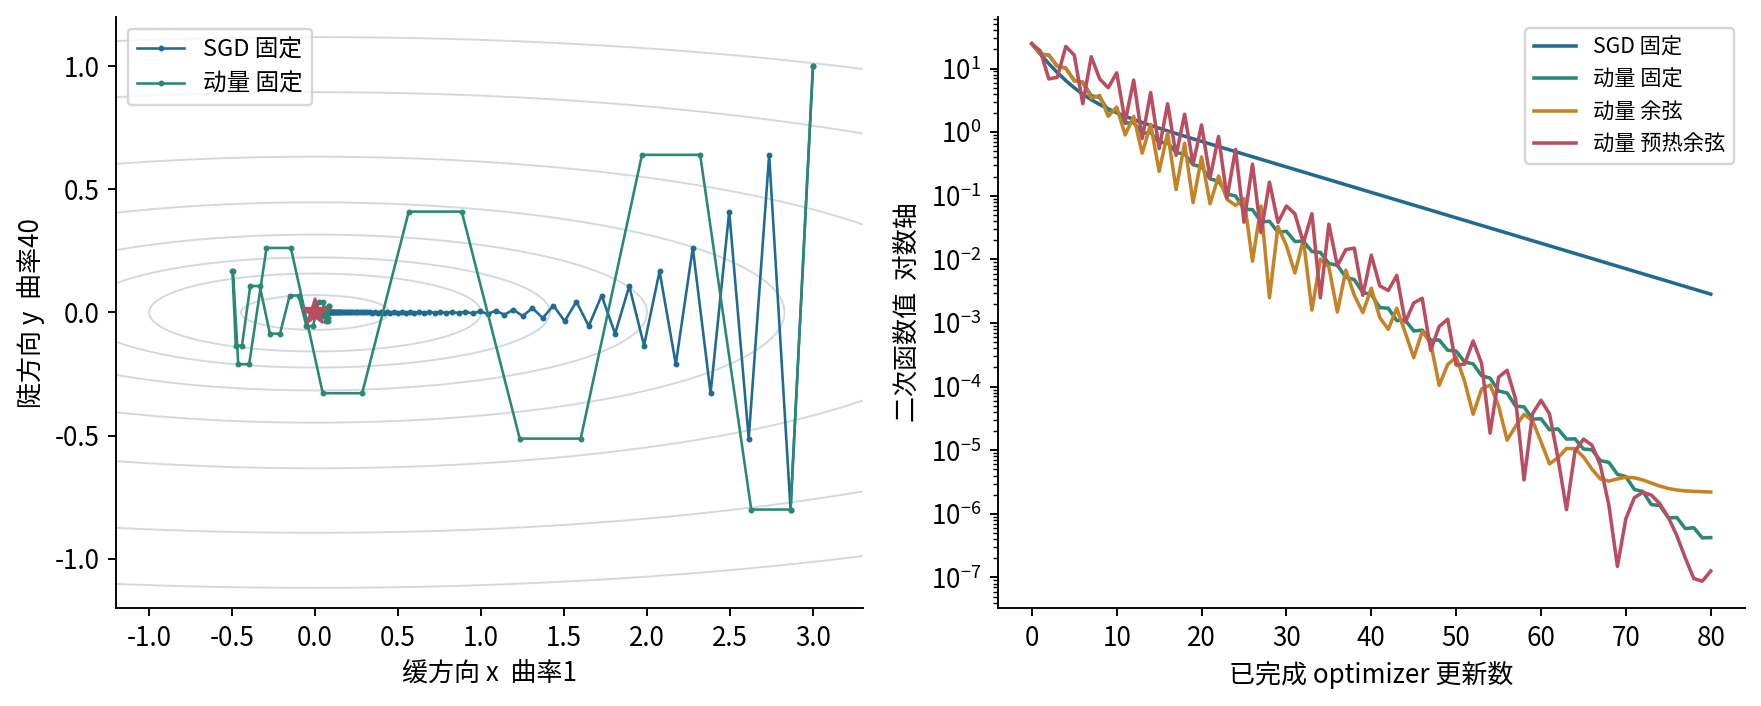

In [11]:
display(Image(filename=str(HERE/'figures/05_quadratic_valley.png'))) 

### 学习率和真实更新时钟
本实验一epoch有12个microbatch但只有6次更新；前12次更新预热。不把scheduler字段名last_epoch当作自动识别epoch的保证。

0 0.005
11 0.06
12 0.05996299743837349
24 0.05398294095933821
71 0.006
72 0.006


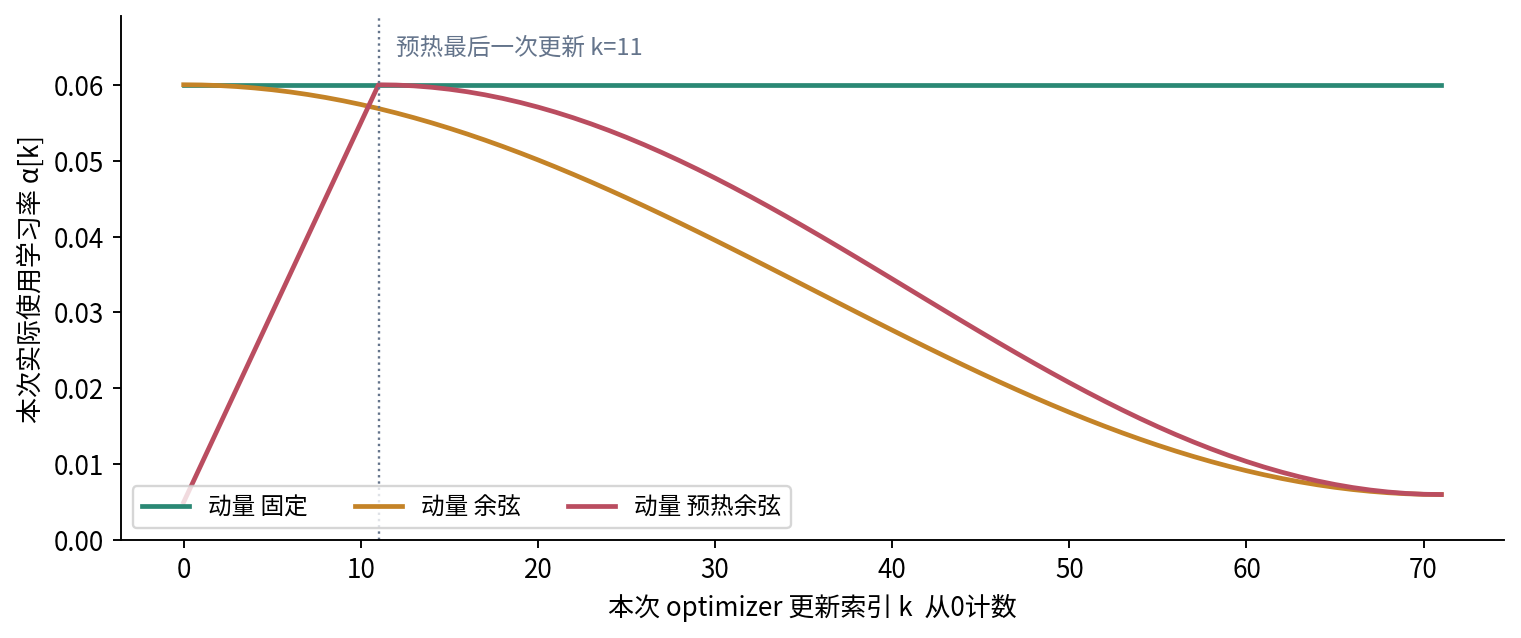

In [12]:
for k in [0,11,12,24,71,72]:
    print(k,e.schedule_lr(k,72,0.06,0.006,12))
display(Image(filename=str(HERE/'figures/06_learning_rate_schedules.png')))

### 相同预算的小网络
每个点是在更新后对固定48点重新评估的half-MSE。没有独立验证/测试集，最终训练loss不估计泛化。

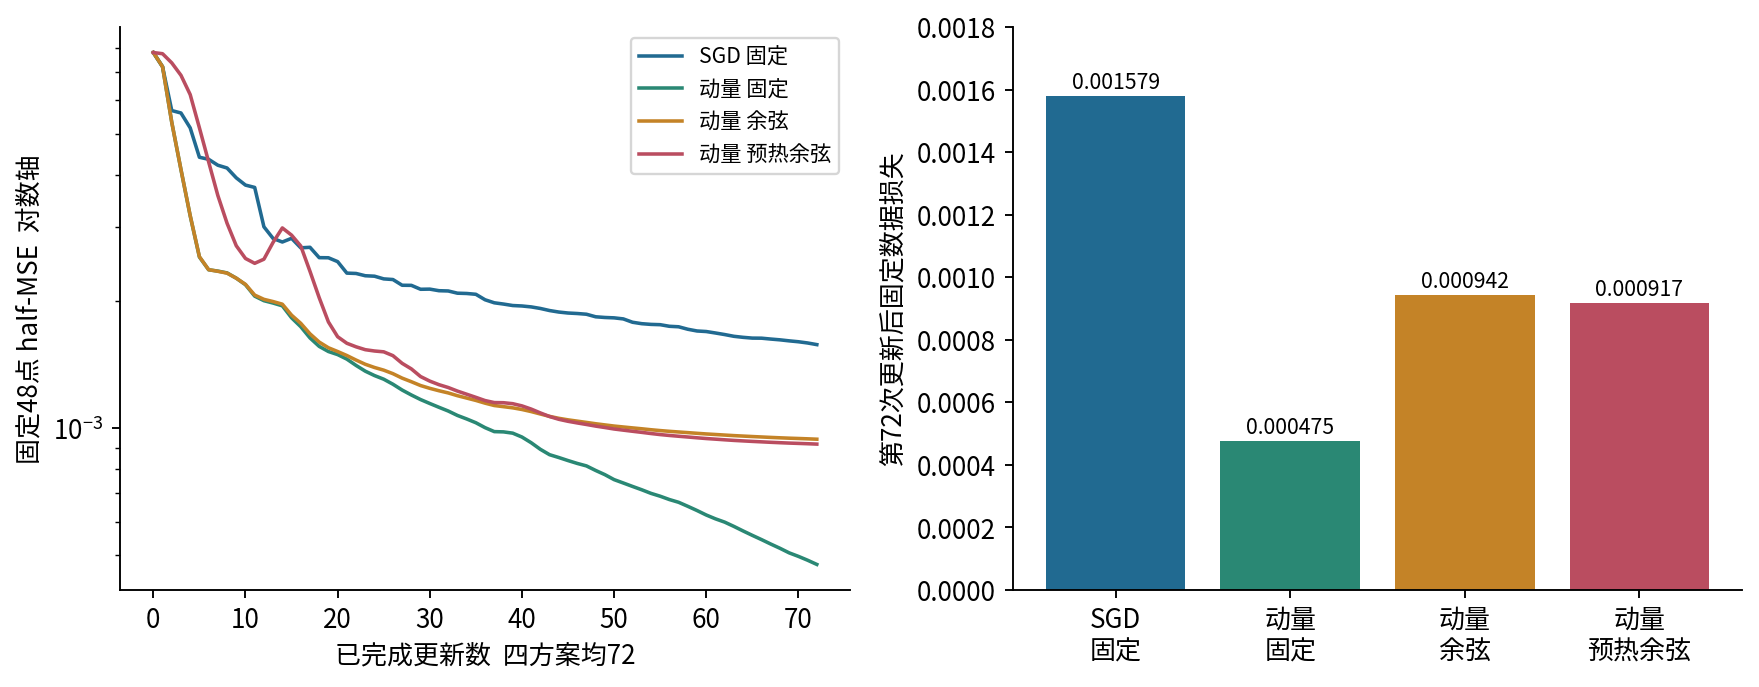

In [13]:
display(Image(filename=str(HERE/'figures/08_network_comparison.png')))

## 恢复与检查
检查点位于epoch4末，24次更新之后。只继续原预算的48次更新，不把恢复当作再追加12epoch。JSON是课程自生成的有界格式；自带摘要只检测意外改动。

完整状态一致 True 剩余更新 48
optimizer 最大参数差 0.005287684053386574 相同顺序 True 恢复后头两个LR [0.05398294095933821, 0.05306491028788964]
rng 最大参数差 0.0005071817927507771 相同顺序 False 恢复后头两个LR [0.05398294095933821, 0.05306491028788964]
scheduler 最大参数差 0.018318295789003333 相同顺序 True 恢复后头两个LR [0.05398294095933821, 0.01]


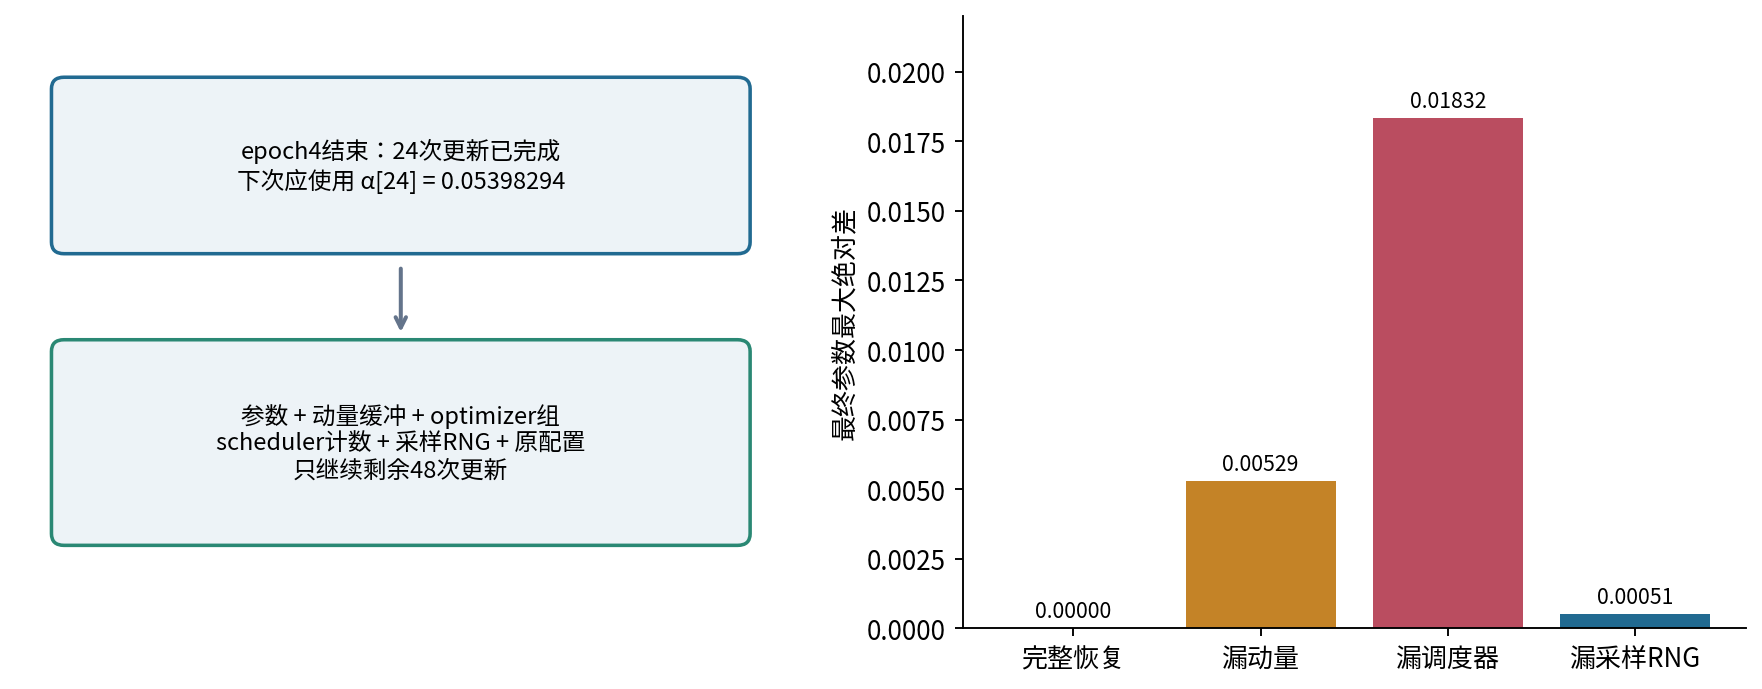

In [14]:
resume = json.loads(blobs['resume.json'])
print('完整状态一致',resume['exact_all_state_equal'],'剩余更新',resume['remaining_updates'])
for name,result in resume['negative_controls'].items():
    print(name,'最大参数差',result['max_parameter_gap'],'相同顺序',result['same_all_orders'],'恢复后头两个LR',result['lr_used_suffix'][:2])
display(Image(filename=str(HERE/'figures/09_resume_state.png')))

### 独立数值与失败条件
运行完整测试：Fraction有理数两次链式计算、18坐标有限差分、EMA枚举、NumPy全轨迹、36次恢复与故意破坏状态等。测试失败会停止，不以assert被-O禁用作为输入防护。

In [15]:
import unittest, test_experiment
suite=unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
result=unittest.TextTestRunner(verbosity=1).run(suite)
if not result.wasSuccessful():
    raise RuntimeError('单元测试失败')
print('通过测试组',result.testsRun)

.

.

.

.

.

...

.

.

.

----------------------------------------------------------------------
Ran 15 tests in 4.140s

OK


通过测试组 15


In [16]:
for name in sorted(blobs):
    recomputed=(HERE/'notebook_outputs'/name).read_bytes()
    reference=(HERE/'outputs'/name).read_bytes()
    if recomputed!=reference:raise RuntimeError('结果不一致: '+name)
    print(name, len(recomputed),hashlib.sha256(recomputed).hexdigest())
print('全部8结果逐字节一致')

checkpoint-epoch-04.json 58754 a0d3cb71a11cc9e996c48979735ae2a13428552ca40f769403b050d3997b5b4b
final-state.json 73235 10317fad9284cb0a9d5d1ea231849409bd18b985401a4f3fdd8db5ccadf7d2e6
network.json 288844 4e75d60a3ff9ffd8a16677fa10224673e66b656109717ef1eba366b236966489
quadratic.json 52983 329845f526d85a3b8d776ab32aa73bc3d808aa6293b8d3e1c349121efb259a28
resume.json 4805 18a63f9e89adcc486ad14dc66c59589e44764b0750435aef26ebcd921ea29578
schedules.csv 4800 eb015af29009c69a481b3a9b7e7ec7c60b1310d1e69ababcd31b62f981c50a69
summary.json 6031 2298cbaf5267b61cf80fa52914f860fa434b378d4c17536e015440d837c23632
trace.json 13115 ac7f3bad7cfa469fdffe2b58e863d9228edac36d1919ade150b8bc37bdd688bb
全部8结果逐字节一致


## 下一步
先不看答案重算W12的两次路径贡献；再在新目录中改变学习率或累积次数，重新列出总预算和LR端点。不要覆盖教材输入和参考图。

只验证CPU完整epoch边界；没有GPU、多worker、分布式、混合精度或累积中途恢复保证。浏览器Jupyter界面和socket传输未测试。资料来自PyTorch 2.7官方文档及原论文，实际查阅范围见sources.md。